# Notebook for setting up and prcoessing the RHINO calibration Gibbs Sampler

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sampler.reader import ObservationReader, ReflectionReader

## Set up observation and reflections

In [2]:
observation = ObservationReader('simulated_data/sim_data.hdf5')
print(np.unique(observation.states_array))

reflection_dict = {'antenna':'simulated_data/antenna_gamma_src.s2p',
                   'heated_load':"simulated_data/heated_load_gamma_src.s2p",
                   'internal_load':'simulated_data/internal_load_gamma_src.s2p',
                   'long_open':'simulated_data/long_open_gamma_src.s2p',
                   'long_short':'simulated_data/long_short_gamma_src.s2p',
                   'open':'simulated_data/open_gamma_src.s2p',
                   'short':'simulated_data/short_gamma_src.s2p',
                   'receiver':'simulated_data/gamma_rec.s2p'}

reflections = ReflectionReader(component_dict=reflection_dict,
                               output_frequencies=observation.freqs,
                               polynomial_interp=True,
                               polynomial_fitting_order=10)

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampl

In [3]:
from sampler.linear_basis import BasisConstructor

## Set up basis functions

In [4]:
print(observation.freqs)
print(np.median(observation.freqs))

print(observation.times[-1] - observation.times[0])

[60000000.         60019550.34213099 60039100.68426198 ...
 79960899.31573804 79980449.65786901 80000000.        ]
70000000.0
3600.0


In [5]:
gains_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=6,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

unc_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=4,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

cos_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=4,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

sin_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=4,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

rx_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

ambient_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

heated_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

antenna_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=3,
                               basis_function='polynomial',
                               time_norm=observation.times[-1] - observation.times[0],
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

## Construct Operators

In [6]:
from sampler.operator_setup import generate_noise_wave_transfer_matrix
from sampler.operator_setup import generate_non_smooth_source_matrix, generate_smooth_source_matrix, generate_noise_wave_transfer_matrix
# Noise Wave Operator
X_noise_wave, nw_slice_dict = generate_noise_wave_transfer_matrix(observation,
                                                               reflections,
                                                               unc_basis,
                                                               cos_basis,
                                                               sin_basis,
                                                               rx_basis)
print(nw_slice_dict)
print(X_noise_wave.shape)


{'unc': slice(0, 4, None), 'cos': slice(4, 8, None), 'sin': slice(8, 12, None), 'rx': slice(12, 13, None)}
(737280, 13)


## Construct Antenna Operator

In [7]:
X_antenna = generate_smooth_source_matrix(observation,
                                          reflections,
                                          source_basis=antenna_basis,
                                          source_label='antenna')

print(X_antenna.shape)

(737280, 3)


### Combine Noisewave and Antenna Operators

In [8]:
from sampler.operator_setup import concat_and_index_operators

X_ant_noisewave = np.concatenate((X_antenna, X_noise_wave), axis=1)

X_ant_noisewave, ant_noise_wave_slice_dict = concat_and_index_operators([X_antenna,
                                                                         X_noise_wave],
                                                                         label_list=['antenna',
                                                                                     'noise_wave'])

print(ant_noise_wave_slice_dict)

{'antenna': slice(0, 3, None), 'noise_wave': slice(3, 16, None)}


## Construct Calibration Source Operator

In [9]:
print(np.unique(observation.switch_states))

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


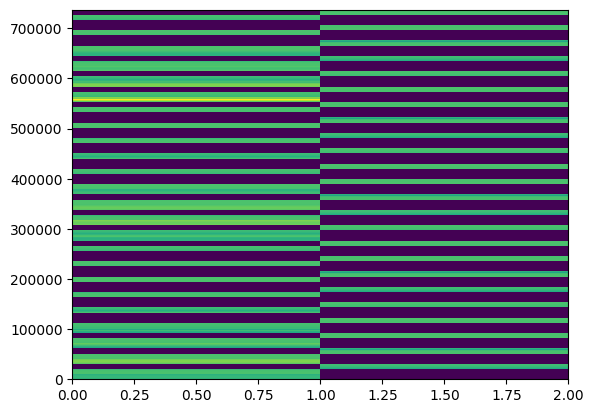

{'ambient': slice(0, 1, None), 'heated': slice(1, 2, None)}


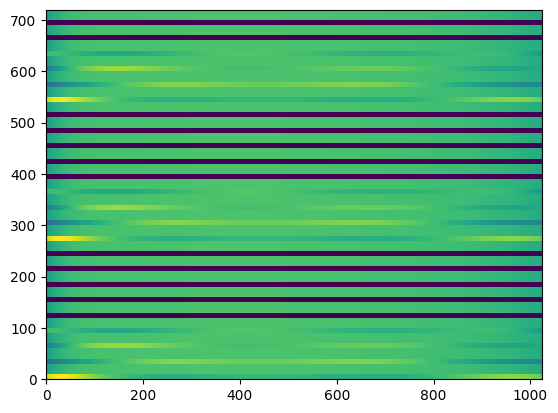

In [10]:
X_ambient = generate_smooth_source_matrix(observation, reflections,
                                          source_basis=ambient_basis,
                                          source_label=['internal_load', 'long_open',
                                                        'long_short', 'open', 'short'])
X_heated = generate_smooth_source_matrix(observation, reflections,
                                         source_basis=heated_basis,
                                         source_label='heated_load')

X_calibrator, calibrator_slice_dict = concat_and_index_operators([X_ambient,
                                                                  X_heated],
                                                                  ['ambient',
                                                                   'heated'])
plt.pcolormesh(X_calibrator)
plt.show()

print(calibrator_slice_dict)

cont = X_calibrator @ np.ones_like(X_calibrator[0])
cont = np.reshape(cont, shape=observation.data_waterfall.shape)
plt.pcolormesh(cont)
plt.show()

In [11]:
print(np.unique(observation.switch_states))

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


### Construct Cal Source Priors

In [12]:
from sampler.priors import setup_probe_cal_priors
cal_source_priors, cal_source_prior_inv_cov = setup_probe_cal_priors(observation,
                                           source_temp_dict={'heated':'heated_load',
                                                             'ambient':['internal_load',
                                                                        'open',
                                                                        'short',
                                                                        'long_open',
                                                                        'long_short']},
                                                                        temp_std=0.05)


In [13]:
print(cal_source_priors)
print(cal_source_prior_inv_cov)
cal_source_prior_inv_cov *= 1000

[292.79509258 292.79509258 292.79509258 ... 493.208712   493.208712
 493.208712  ]
[400. 400. 400. ... 400. 400. 400.]


In [14]:
### Attempt a Weiner solution fit

from sampler.gibbs_sample import construct_gcr_lhs, construct_gcr_rhs, solve_gcr





cal_source_lhs = construct_gcr_lhs(linear_operator=X_calibrator,
                                   inv_data_cov=cal_source_prior_inv_cov,
                                   inv_prior_cov=None,
                                   prior_in_data_space=True)
cal_source_rhs = construct_gcr_rhs(linear_operator=X_calibrator,
                                   data=cal_source_priors,
                                   inv_data_cov=cal_source_prior_inv_cov,
                                   omega_data=np.zeros_like(observation.data_waterfall.flatten()),
                                   priors=None,
                                   inv_prior_cov=None,
                                   weiner_solution=True,
                                   prior_in_data_space=True)

init_calibrator_solution = solve_gcr(cal_source_lhs, cal_source_rhs,linalg_init=False,
                                     atol=1e-12, rtol=1e-14, maxiter=int(1e6))




init_calibrator_solution = np.array([np.mean(observation.temperatures['ambient']),
                                     np.mean(observation.temperatures['heated'])])

print(init_calibrator_solution)
# ambient_amps, heated_amps = init_calibrator_solution[:4], init_calibrator_solution[4:]
# print(ambient_amps)
# print(heated_amps)

# reconstructed_ambient = ambient_basis.basis_matrix @ ambient_amps
# reconstructed_heated = ambient_basis.basis_matrix @ heated_amps

# plt.pcolormesh(np.reshape(reconstructed_ambient, shape=observation.data_waterfall.shape))
# plt.colorbar()
# plt.show()

# plt.pcolormesh(np.reshape(reconstructed_heated, shape=observation.data_waterfall.shape))
# plt.colorbar()
# plt.show()

[293.00308719 492.99506746]


In [15]:
# cal_source_priors = np.array([np.mean(observation.temperatures['ambient']),
#                                      np.mean(observation.temperatures['heated'])])
# cal_source_prior_inv_cov = np.ones_like(cal_source_priors) * (1 / 0.0005)

print(cal_source_prior_inv_cov)

[400000. 400000. 400000. ... 400000. 400000. 400000.]


In [16]:
## Construct cal source priors from raw temperatures

## Gain Operator

In [17]:
U_gain = gains_basis.basis_matrix
print(U_gain.shape)
# plt.pcolormesh(U_gain)
# plt.show()

(737280, 6)


In [18]:
print(observation.temperatures)

{'heated': array([492.938214  , 492.99245448, 493.18284858, 492.94097043,
       493.13034769, 492.91769358, 492.74005132, 492.91135072,
       492.9373744 , 492.9328143 , 493.06942727, 493.0438689 ,
       493.02821153, 492.81314645, 493.04676388, 493.0479166 ,
       492.88973895, 492.93770312, 492.99532682, 492.93901526,
       492.90630652, 493.00614262, 492.97791536, 492.95391407,
       492.90036048, 492.8955135 , 492.87941981, 492.9497619 ,
       493.20562304, 492.96089831, 492.8795704 , 492.89534726,
       492.9598097 , 493.12123148, 492.92709037, 492.98785571,
       493.14728749, 493.01838098, 492.92444288, 493.03890632,
       493.06601052, 492.92552722, 493.00307157, 492.91894376,
       493.10689705, 493.03434324, 493.07704401, 492.86020396,
       493.09223772, 492.95741873, 493.09528488, 493.09698471,
       492.95885261, 493.15130637, 493.04293744, 492.93979976,
       493.07582996, 493.17109097, 493.10365676, 492.95755826,
       493.05207083, 492.98461925, 493.07106

In [19]:
# get an initial guess of the gains params

def init_gain_guess(observation_obj: ObservationReader,
                    reflections_obj: ReflectionReader,
                    gains_basis: BasisConstructor,
                    noise_source_label: str = "heated_load",
                    load_label: str = 'internal_load',
                    noise_source_temp: int | None = None):

    noise_source_mask = (observation_obj.states_array == noise_source_label)
    load_mask = (observation_obj.states_array == load_label)
    p_ns = observation_obj.data_waterfall[noise_source_mask].mean(axis=0)
    p_l = observation_obj.data_waterfall[load_mask].mean(axis=0)

    if noise_source_temp is not None: t_ns = noise_source_temp
    else:
        t_ns = np.mean(observation_obj.temperatures['heated'])
    t_l = np.mean(observation_obj.temperatures['ambient'])

    gamma_rec = reflections_obj.s11_dict['receiver']

    mean_gain = (p_ns - p_l) / ((t_ns - t_l) * (1 - np.power(np.abs(gamma_rec), 2)))

    fitting_gain = np.zeros_like(observation.data_waterfall)
    fitting_gain[:,:] = mean_gain
    fitting_gain = fitting_gain.flatten()
    init_amp_guess = np.linalg.lstsq(gains_basis.basis_matrix, fitting_gain)[0]

    return init_amp_guess

init_gain_amps = init_gain_guess(observation, reflections, gains_basis)

# Set up Gibbs Sampler

In [20]:
from sampler.gibbs_sample import sample_loop

In [21]:
print(init_calibrator_solution)

[293.00308719 492.99506746]


In [22]:
param_dict = sample_loop(data=observation.data_waterfall.flatten(),
                         N=observation.Nw.flatten(),
                         U_gain=U_gain,
                         X_ant_nw=X_ant_noisewave,
                         X_cal_src=X_calibrator,
                         init_gain_amps=init_gain_amps,
                         init_cal_src_amps=init_calibrator_solution,
                         init_ant_nw_amps=np.ones_like(X_ant_noisewave[0]),
                         cal_src_priors=cal_source_priors,
                         inv_cal_src_prior_cov=cal_source_prior_inv_cov, n_iter=200,
                         fix_cal_source=True,
                         verbose=True)

d_cont  [461.34603847 459.99201601 453.85768838 ... 433.53003783 433.75914858
 431.79460714]
inv_cont_cov  [0.00081169 0.00079771 0.0007845  ... 0.00047503 0.00047643 0.00047786]
p_ant_nw - 0
[ 19868.22224857 -47211.12634011  30159.40823472   3573.4198665
  -9767.33600622   8766.47627665  -2568.43729231  -7298.79441902
  21917.36863217 -21839.696353     7253.35523043  -4749.64357183
  14505.45437934 -14680.24787601   4948.45496941    406.53811635]
d_gain  [91.87999626 91.91129185 91.41192084 ... 17.74232359 17.52158742
 17.25599322]
d_gain_inv_cov  [0.01137669 0.01135703 0.01133756 ... 0.32175389 0.33050109 0.33962842]
p_gain - 0
[ -2987.62242982   3548.55088778  15088.81387706 -38074.44782398
  31376.20421942  -8863.8078683 ]
p_cal_src - 0
[293.00308719 492.99506746]
Gibbs Sample - 0 / 200
d_cont  [429.75899155 428.94401934 423.52590998 ... 426.05127167 426.70782817
 425.21052609]
inv_cont_cov  [0.00077431 0.00076075 0.00074798 ... 0.00047529 0.00047669 0.00047812]
p_ant_nw - 1
[ 1764

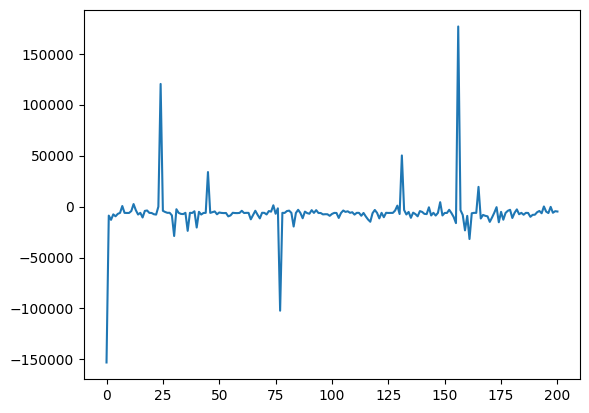

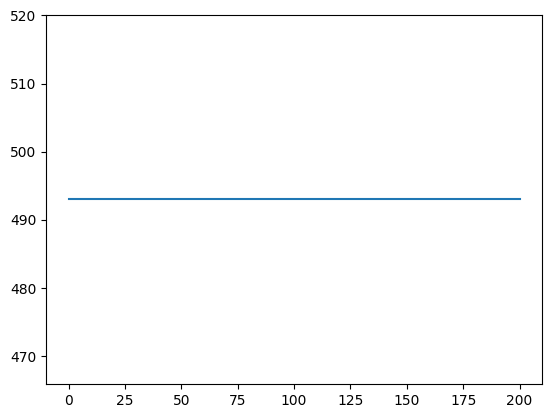

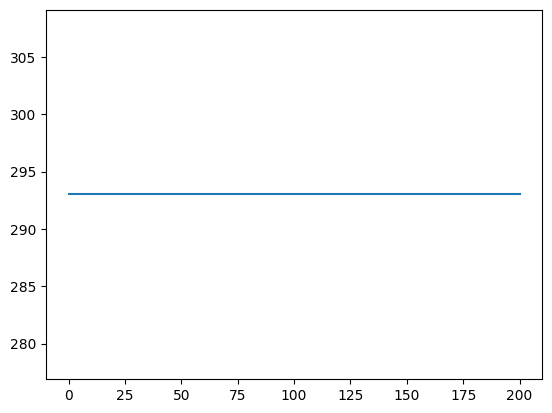

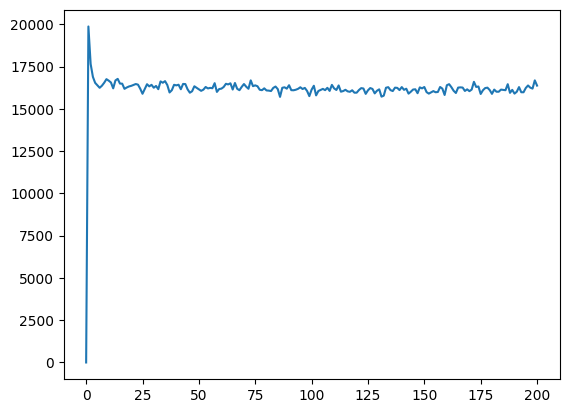

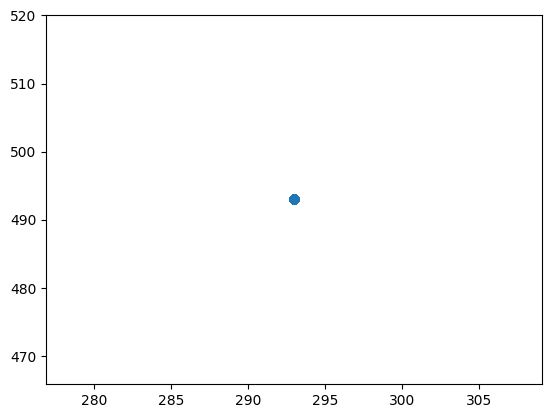

In [23]:
plt.plot(param_dict['all_p_gain'][:,-1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, -1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, 0])
plt.show()
plt.plot(param_dict['all_p_ant_nw'][:, 0])
plt.show()

plt.scatter(param_dict['all_p_cal_src'][:, 0], param_dict['all_p_cal_src'][:, 1])
plt.show()

In [24]:
param_dict = sample_loop(data=observation.data_waterfall.flatten(),
                         N=observation.Nw.flatten(),
                         U_gain=U_gain,
                         X_ant_nw=X_ant_noisewave,
                         X_cal_src=X_calibrator,
                         init_gain_amps=np.median(param_dict['all_p_gain'], axis=0),
                         init_cal_src_amps=init_calibrator_solution,
                         init_ant_nw_amps=np.median(param_dict['all_p_ant_nw'], axis=0),
                         cal_src_priors=cal_source_priors,
                         inv_cal_src_prior_cov=cal_source_prior_inv_cov, n_iter=1000,
                         fix_cal_source=True,
                         verbose=False)

Gibbs Sample - 0 / 1000
Gibbs Sample - 50 / 1000
Gibbs Sample - 100 / 1000
Gibbs Sample - 150 / 1000
Gibbs Sample - 200 / 1000
Gibbs Sample - 250 / 1000
Gibbs Sample - 300 / 1000
Gibbs Sample - 350 / 1000
Gibbs Sample - 400 / 1000
Gibbs Sample - 450 / 1000
Gibbs Sample - 500 / 1000
Gibbs Sample - 550 / 1000
Gibbs Sample - 600 / 1000
Gibbs Sample - 650 / 1000
Gibbs Sample - 700 / 1000
Gibbs Sample - 750 / 1000
Gibbs Sample - 800 / 1000
Gibbs Sample - 850 / 1000
Gibbs Sample - 900 / 1000
Gibbs Sample - 950 / 1000


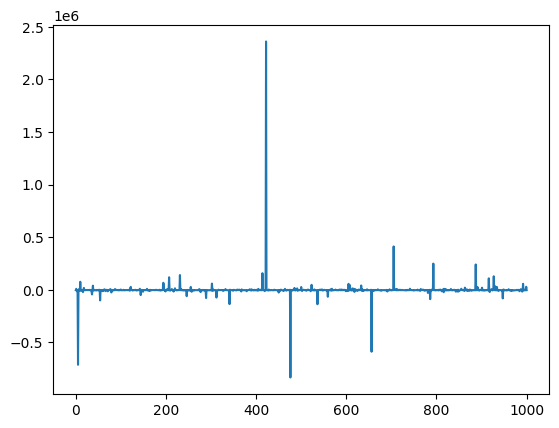

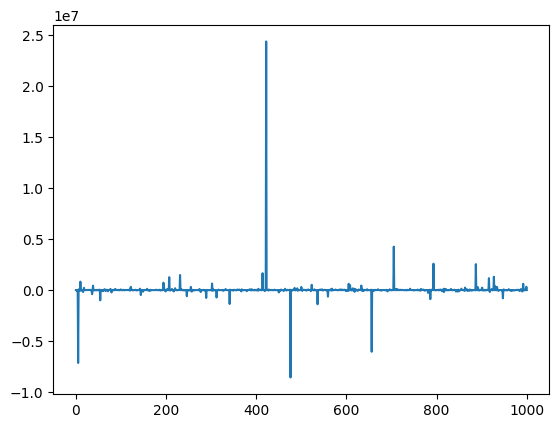

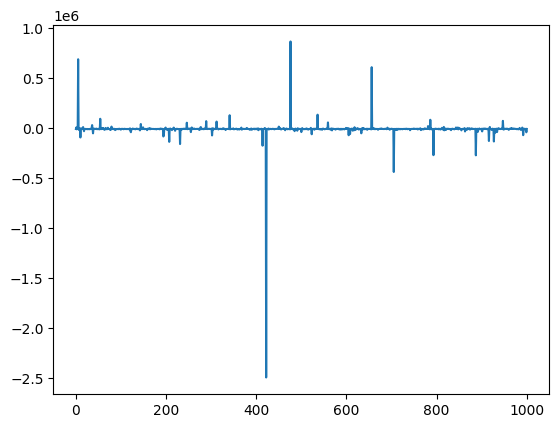

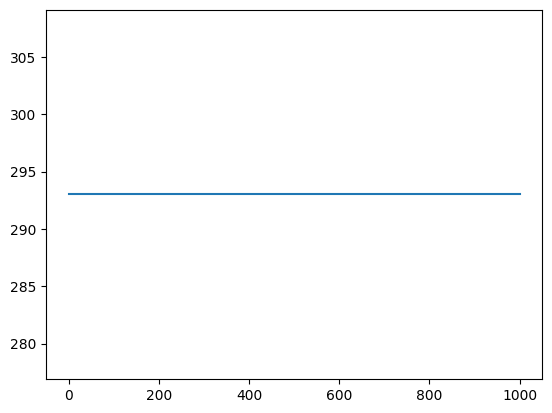

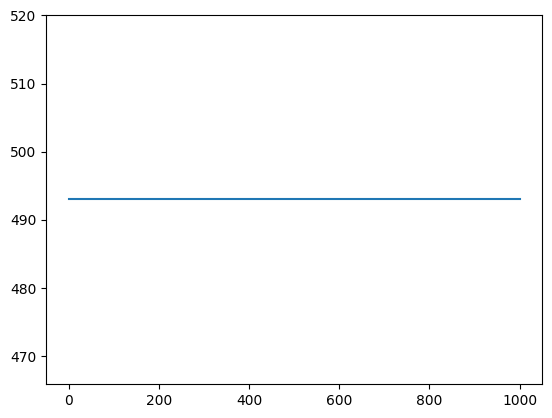

492.99506746414977


In [25]:
plt.plot(param_dict['all_p_gain'][:,0])
plt.show()
plt.plot(param_dict['all_p_gain'][:,2])
plt.show()
plt.plot(param_dict['all_p_gain'][:,-1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, 0])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, -1])
plt.show()


print(np.median(param_dict['all_p_cal_src'][:, -1]))





[  6518.0440425  -19505.32007017  19347.88549781  -6349.06985313
  -5047.83463024  14963.16144922 -14701.68673993   4818.88393499
    662.13116035  -1450.61269378    918.12777702   -110.70445818
    391.16919514]


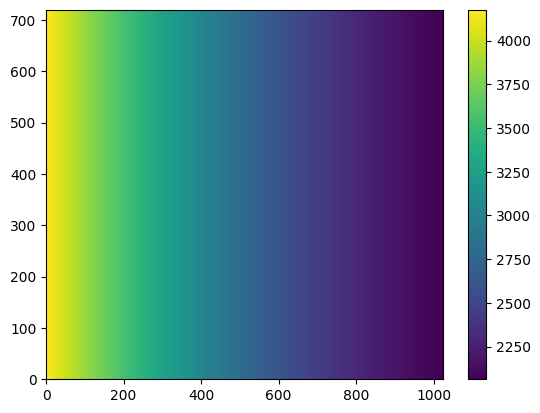

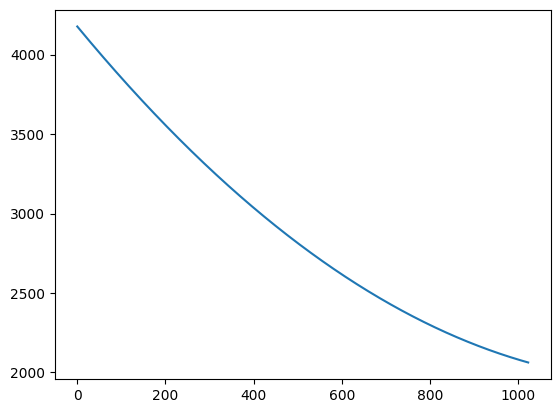

In [26]:
# Recovered Antenna

median_p_ant_nw = np.mean(param_dict['all_p_ant_nw'], axis=0)
median_p_ant = median_p_ant_nw[:len(X_antenna[0])]
median_p_nw = median_p_ant_nw[len(X_antenna[0]):]
print(median_p_nw)


reconstructed_antenna = antenna_basis.basis_matrix @ median_p_ant
reconstructed_antenna = np.reshape(reconstructed_antenna, shape=observation.data_waterfall.shape)

plt.pcolormesh(reconstructed_antenna)
plt.colorbar()
plt.show()

plt.plot(reconstructed_antenna.mean(axis=0))
plt.show()

[ -5816.17727179  17341.75390387 -11940.30135231 -11522.75300258
  18316.98606891  -6275.53148968]


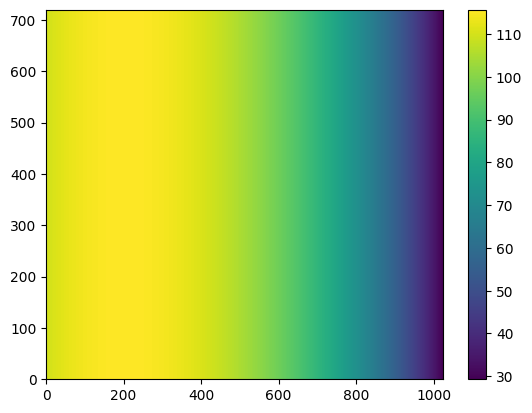

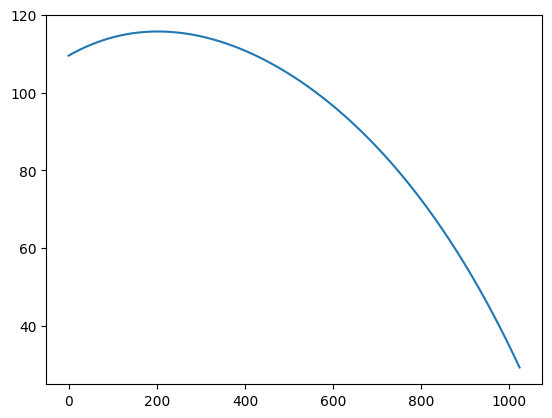

In [27]:
median_gains = np.median(param_dict['all_p_gain'], axis=0)

print(median_gains)

reconstructed_gains = gains_basis.basis_matrix @ median_gains

reconstructed_gains = np.reshape(reconstructed_gains, shape=observation.data_waterfall.shape)

plt.pcolormesh(reconstructed_gains)
plt.colorbar()
plt.show()

plt.plot(np.mean(reconstructed_gains, axis=0))
plt.show()

In [28]:
import h5py
sim_filepath = 'simulated_data/sim_data.hdf5_sim'
with h5py.File(sim_filepath) as f:
    t_unc_sim = f['t_unc'][()]
    t_sin_sim = f['t_sin'][()]
    t_cos_sim = f['t_cos'][()]
    t_rx_sim = f['t_0'][()]
    gain_sim = f['gains'][()]

## Gain Recovery

[ -3964.5895759    7908.36505382   7264.68692704 -30986.43419615
  28115.24406428  -8248.05957881]


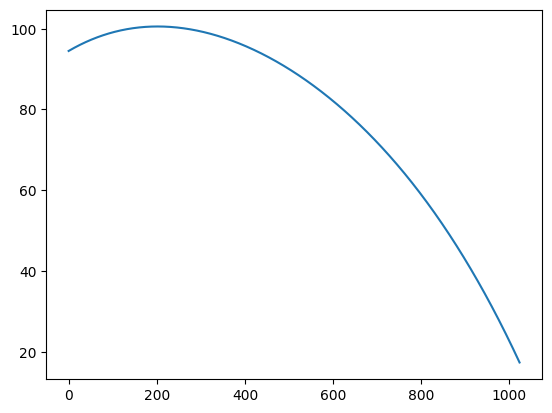

In [37]:
median_gains = np.mean(param_dict['all_p_gain'], axis=0)

print(median_gains)

reconstructed_gains = gains_basis.basis_matrix @ median_gains

reconstructed_gains = np.reshape(reconstructed_gains, shape=observation.data_waterfall.shape)

plt.plot(np.mean(reconstructed_gains, axis=0))
plt.show()

In [38]:
def compare_sim_and_recontructed(simulated_surface,
                                 basis_obj:BasisConstructor,
                                 amplitudes,
                                 times,
                                 freqs,
                                 cmap_rec='viridis',
                                 cmap_res='RdBu',
                                 perc_diff=False,
                                 surface_label='',
                                 figsize=(10,8)):
    fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, sharex=True, layout='constrained',
                                        figsize=figsize)

    recovered_surface = basis_obj.basis_matrix @ amplitudes
    recovered_surface = np.reshape(recovered_surface, shape=simulated_surface.shape)

    vmin = np.min(np.array([simulated_surface, recovered_surface]))
    vmax = np.max(np.array([simulated_surface, recovered_surface]))
    
    im1 = ax1.pcolormesh(freqs, times, simulated_surface, cmap=cmap_rec, vmin=vmin, vmax=vmax)
    ax1.set_title('True Simulated')

    
    im2 = ax2.pcolormesh(freqs, times, recovered_surface, cmap=cmap_rec, vmin=vmin, vmax=vmax)
    ax2.set_title('Recovered')


    if perc_diff:
        res = 200 * (recovered_surface - simulated_surface) / (recovered_surface+simulated_surface)
    else:
        res = recovered_surface - simulated_surface
    
    im3 = ax3.pcolormesh(freqs, times, res, cmap=cmap_res)

    fig.colorbar(im1, ax=[ax1, ax2], label=surface_label)

    if perc_diff:
        res_label='% Difference'
    else:
        res_label='Residual [K]'
    fig.colorbar(im3, ax=ax3, label=res_label)

    fig.supxlabel('Freqs')
    fig.supylabel('Time')
    plt.show()
    

## Noise Wave Param Recovery

In [39]:
param_dict['all_p_ant_nw'][ant_noise_wave_slice_dict['noise_wave']]

mean_ant_nw = param_dict['all_p_ant_nw'].mean(axis=0)

median_ant_nw = np.median(param_dict['all_p_ant_nw'], axis=0)

# print(ant_noise_wave_slice_dict['noise_wave'])

mean_nw = mean_ant_nw[ant_noise_wave_slice_dict['noise_wave']]
print(nw_slice_dict)

mean_unc = mean_nw[nw_slice_dict['unc']]
mean_cos = mean_nw[nw_slice_dict['cos']]
mean_sin = mean_nw[nw_slice_dict['sin']]
mean_rx = mean_nw[nw_slice_dict['rx']]

print(mean_unc, mean_cos, mean_sin, mean_rx)

{'unc': slice(0, 4, None), 'cos': slice(4, 8, None), 'sin': slice(8, 12, None), 'rx': slice(12, 13, None)}
[  6518.0440425  -19505.32007017  19347.88549781  -6349.06985313] [ -5047.83463024  14963.16144922 -14701.68673993   4818.88393499] [  662.13116035 -1450.61269378   918.12777702  -110.70445818] [391.16919514]


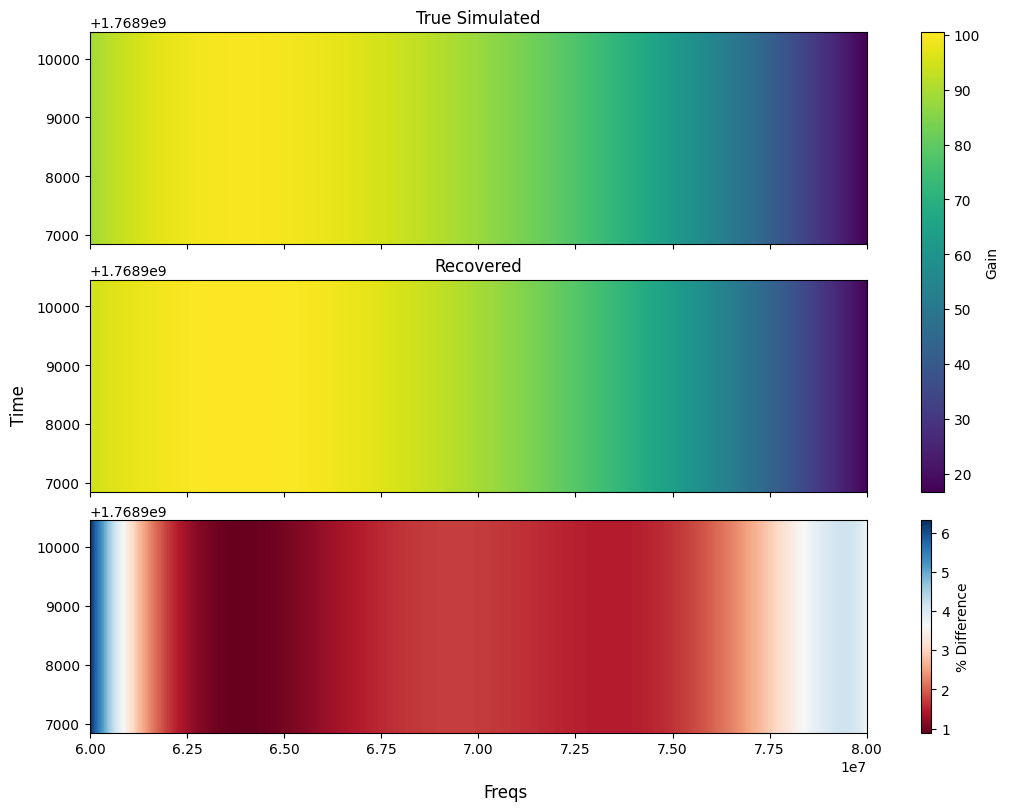

In [40]:
compare_sim_and_recontructed(gain_sim,
                             gains_basis,
                             median_gains,
                             observation.times,
                             observation.freqs,
                             surface_label='Gain',
                             perc_diff=True)

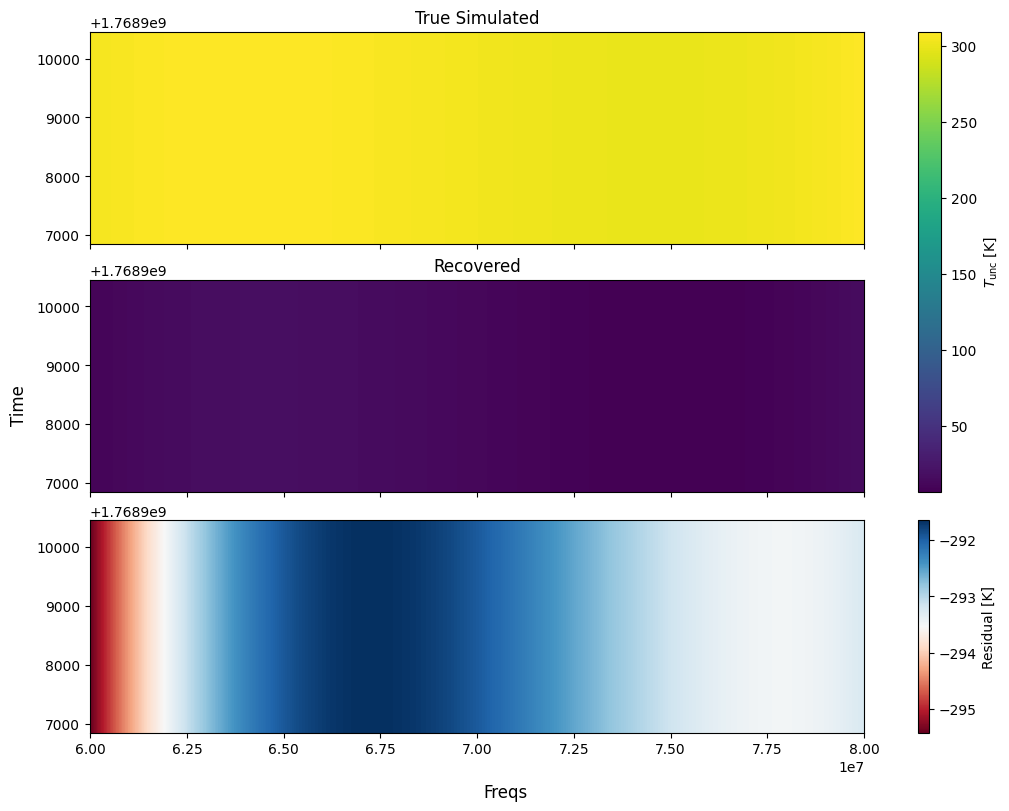

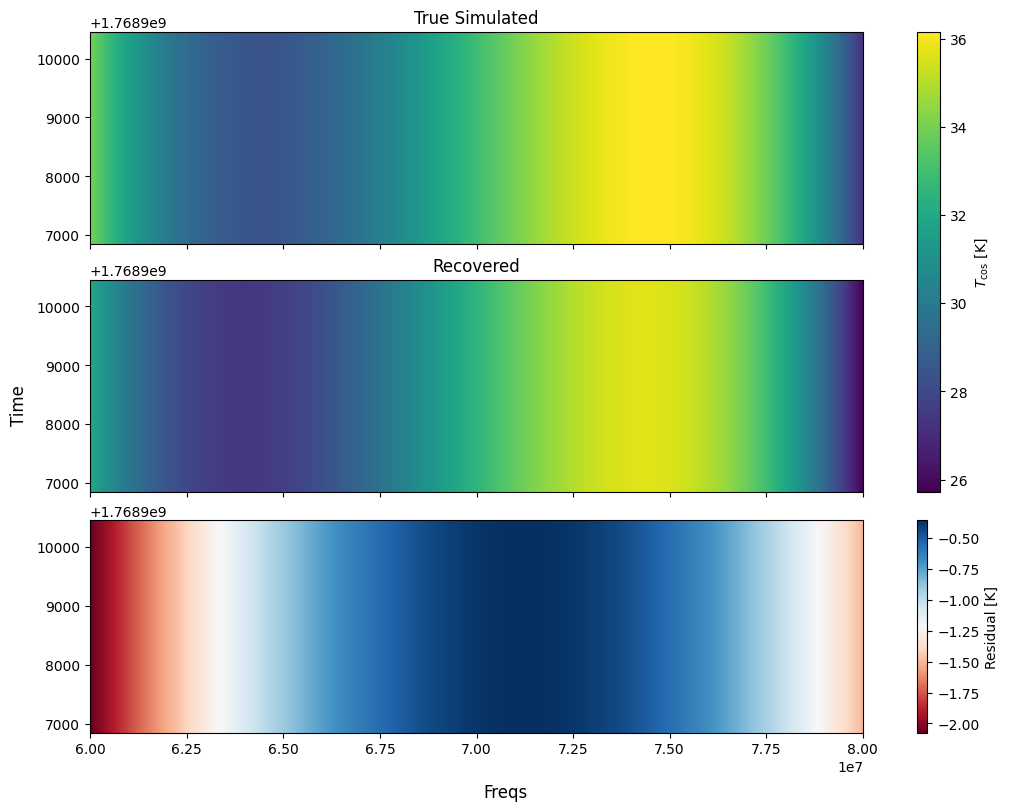

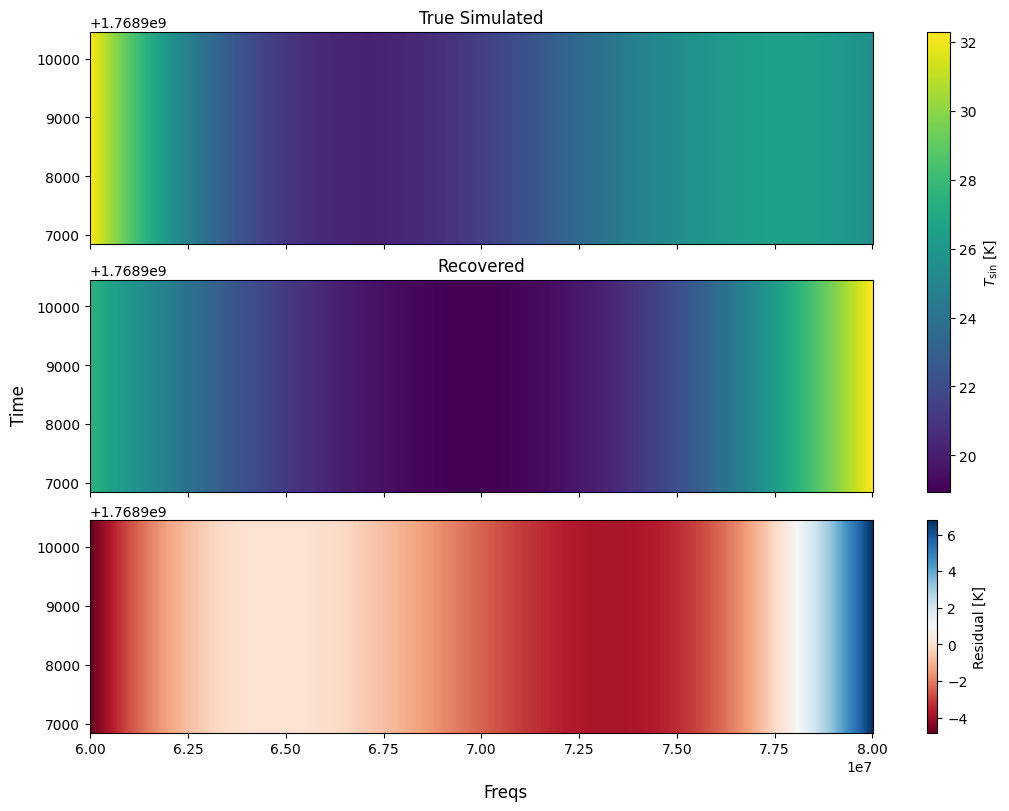

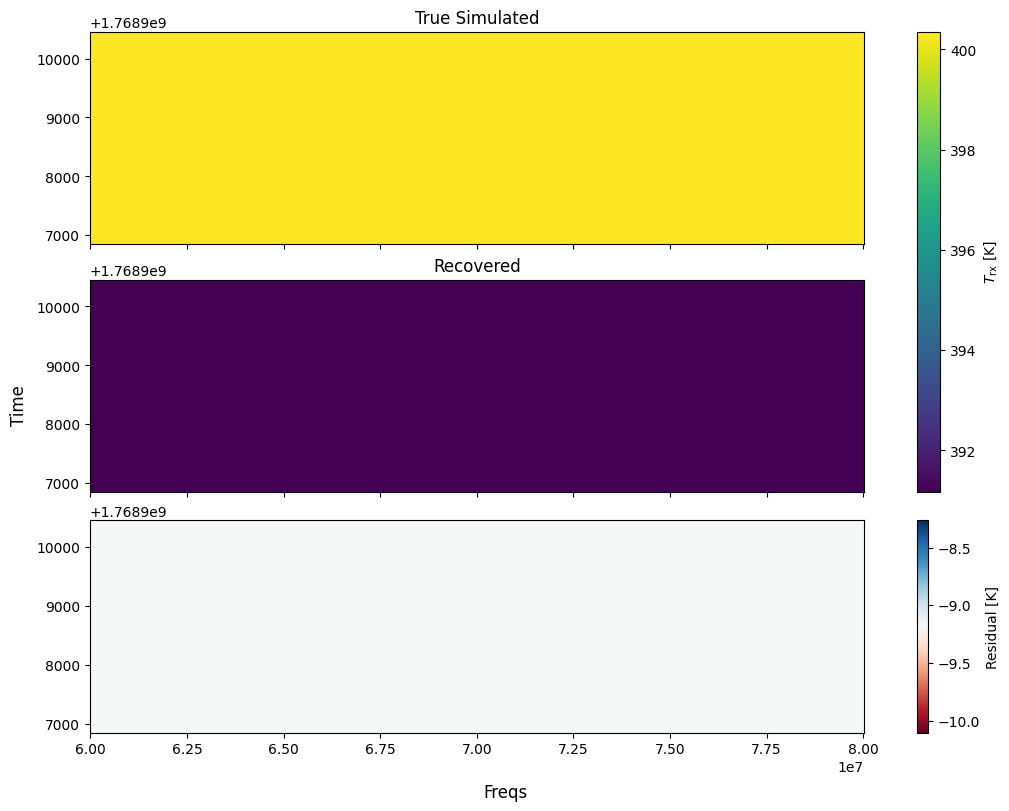

In [41]:
compare_sim_and_recontructed(t_unc_sim,
                             unc_basis,
                             mean_unc,
                             observation.times,
                             observation.freqs,
                             surface_label=r'$T_{\rm unc}$ [K]')
compare_sim_and_recontructed(t_cos_sim,
                             cos_basis,
                             mean_cos,
                             observation.times,
                             observation.freqs,
                             surface_label=r'$T_{\rm cos}$ [K]')
compare_sim_and_recontructed(t_sin_sim,
                             sin_basis,
                             mean_sin,
                             observation.times,
                             observation.freqs,
                             surface_label=r'$T_{\rm sin}$ [K]')
compare_sim_and_recontructed(t_rx_sim,
                             rx_basis,
                             mean_rx,
                             observation.times,
                             observation.freqs,
                             surface_label=r'$T_{\rm rx}$ [K]')